# Simple Linear Regression using scikit-learn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

## Load Dataset

In [11]:
df = pd.read_csv("Loan_default.csv")

## Select Feature and Target

In [12]:
x = df[["Income"]]
y = df["LoanAmount"]

print(x)
print(y)

        Income
0        85994
1        50432
2        84208
3        31713
4        20437
...        ...
255342   37979
255343   51953
255344   84820
255345   85109
255346   22418

[255347 rows x 1 columns]
0          50587
1         124440
2         129188
3          44799
4           9139
           ...  
255342    210682
255343    189899
255344    208294
255345     60575
255346     18481
Name: LoanAmount, Length: 255347, dtype: int64


## Split Dataset

In [13]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size = 0.2,
    random_state = 42
)

## Train Model

In [14]:
model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[-0.]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Income']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.276e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [15]:
print("Slope (m):", model.coef_[0])
print("Intercept (c):", model.intercept_)

Slope (m): -0.00120319575179821
Intercept (c): 127646.76753760346


## Predict

In [16]:
y_pred = model.predict(x_test)

## Performance

In [17]:
print("MSE :", mean_squared_error(y_test, y_pred))

print("R2 Score :", r2_score(y_test, y_pred))

MSE : 5010263546.515545
R2 Score : -3.1205242614351647e-06


## Regression Line

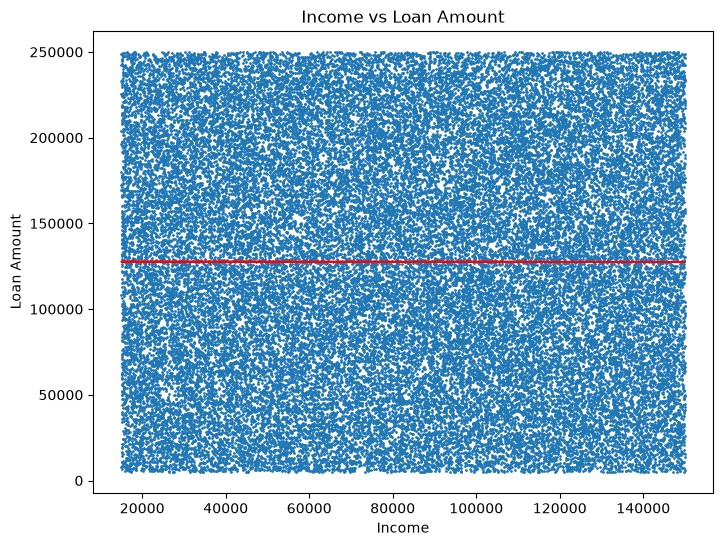

In [18]:
plt.figure(figsize = (8, 6))

plt.scatter(x_test, y_test, s = 1)

plt.plot(x_test, y_pred, color = "red")

plt.xlabel("Income")

plt.ylabel("Loan Amount")

plt.title("Income vs Loan Amount")

plt.show()

In [19]:
print(y_test)
print(y_pred)

51139      92393
71005     131575
35684      75417
174087     10804
137952     21182
           ...  
35991     170353
69680     111314
184743    142666
209406    190938
123164     83956
Name: LoanAmount, Length: 51070, dtype: int64
[127511.22031699 127536.59210581 127552.71492888 ... 127540.2762912
 127506.41595635 127537.97457773]


# Gradient Descent From Scratch

## Convert into NumPy Arrays

In [20]:
df = pd.read_csv("Loan_default_cleaned.csv")

In [21]:
X = df["income"].values

Y = df["loanamount"].values

print(X)
print(Y)

[ 0.08969281 -0.82302071  0.04385438 ...  0.05956161  0.06697892
 -1.54201168]
[-1.08683299 -0.04430887  0.02271487 ...  1.13939142 -0.94584033
 -1.54004788]


## Gradient Descent

In [22]:
m = 0

c = 0

learning_rate = 0.001

epochs = 10000

n = len(X)

loss_history = []

for i in range(epochs):

    Y_pred = m * X + c

    error = Y_pred - Y

    loss = (1/n) * np.sum(error**2)

    loss_history.append(loss)

    dm = (2/n) * np.sum(error * X)

    dc = (2/n) * np.sum(error)

    m = m - learning_rate * dm

    c = c - learning_rate * dc

    if i % 1000 == 0:
        print("Epoch:", i)
        print("Loss:", loss)

print("Final Slope :", m)

print("Final Intercept :", c)

Epoch: 0
Loss: 1.0000000000000002
Epoch: 1000
Loss: 0.9999992648712276
Epoch: 2000
Loss: 0.9999992514606959
Epoch: 3000
Loss: 0.9999992512160554
Epoch: 4000
Loss: 0.9999992512115925
Epoch: 5000
Loss: 0.9999992512115111
Epoch: 6000
Loss: 0.9999992512115095
Epoch: 7000
Loss: 0.9999992512115096
Epoch: 8000
Loss: 0.9999992512115095
Epoch: 9000
Loss: 0.9999992512115095
Final Slope : -0.0008653256541776203
Final Intercept : 4.104864880443508e-17


## Prediction

In [23]:
prediction = m * X + c

## Loss Curve

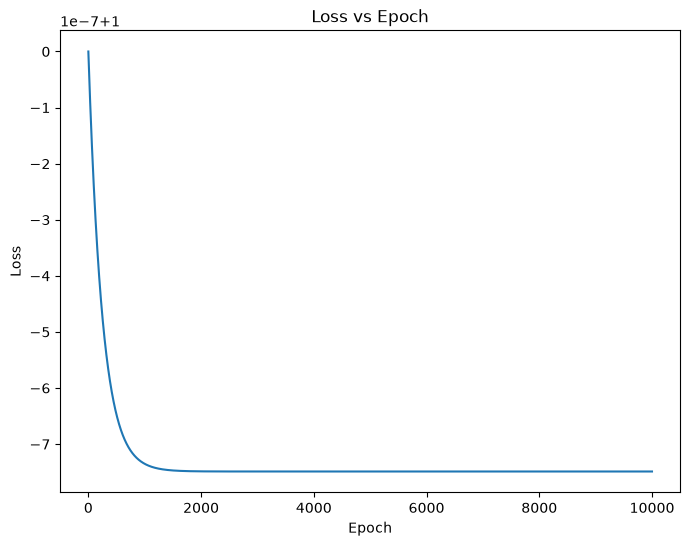

In [24]:
plt.figure(figsize=(8,6))

plt.plot(loss_history)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Loss vs Epoch")

plt.show()

## Regression Line

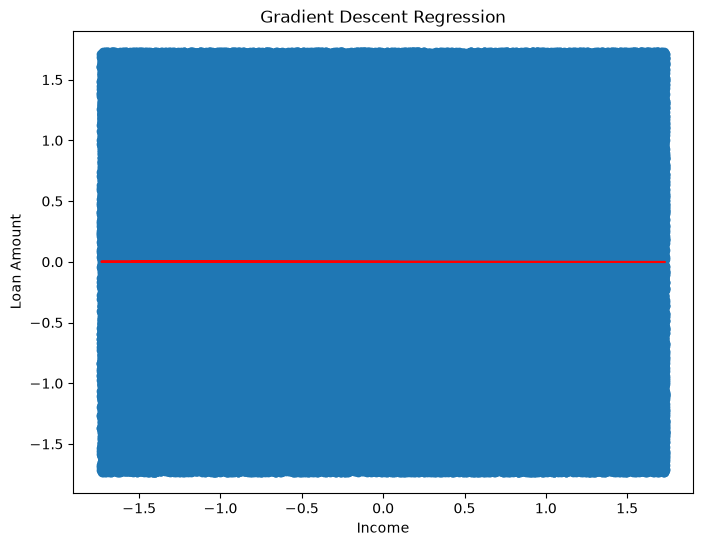

In [25]:
plt.figure(figsize=(8,6))

plt.scatter(X, Y)

plt.plot(X, prediction, color="red")

plt.xlabel("Income")

plt.ylabel("Loan Amount")

plt.title("Gradient Descent Regression")

plt.show()

## Compare Both Methods

In [26]:
print("Sklearn Slope :", model.coef_[0])

print("Gradient Descent Slope :", m)

print()

print("Sklearn Intercept :", model.intercept_)

print("Gradient Descent Intercept :", c)

Sklearn Slope : -0.00120319575179821
Gradient Descent Slope : -0.0008653256541776203

Sklearn Intercept : 127646.76753760346
Gradient Descent Intercept : 4.104864880443508e-17
